In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
plt.style.use("classic")

In [2]:
t0=0 # [hrs]
t1=2 # [hrs]
dt=0.005 # [hrs]

t = np.arange(t0, t1+dt, dt)

In [3]:
x=800*t # [km]

In [4]:
altitude=2 # [km]
y=np.ones(len(t))*altitude

In [5]:
speed_x = np.sin(np.linspace(0, 3*np.pi, len(t)))
x = np.cumsum(speed_x) * dt

In [6]:
t[np.where(t == 1.0)], speed_x[np.where(t == 1.0)], x[np.where(t == 1.0)]

(array([1.]), array([-1.]), array([0.20969677]))

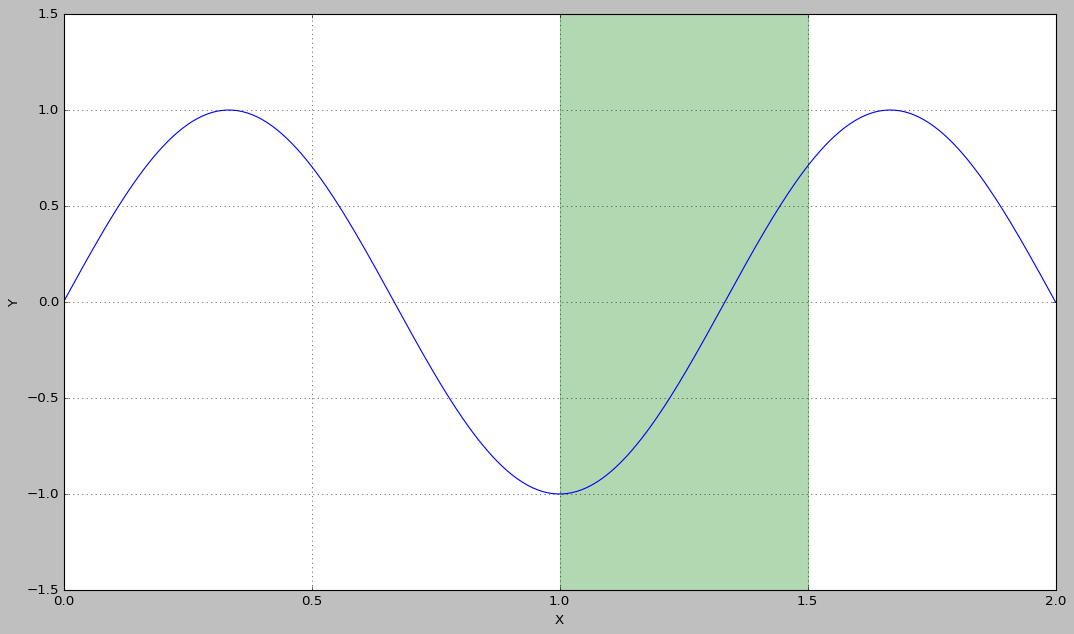

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

ax.plot(t, speed_x)
ax.grid('True')
ax.set_yticks(np.arange(-1.5, 1.5+0.5, 0.5))
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.axvspan(1.0, 1.5, label="Time Window", color="green", alpha=0.3)

In [8]:
frame_amount = len(t)
dot = np.zeros(frame_amount)

In [9]:
n=20
for i in range(0,frame_amount):
    if i == n:
        dot[i] = x[i]
        n=n+20
    else:
        dot[i] = x[n-20]

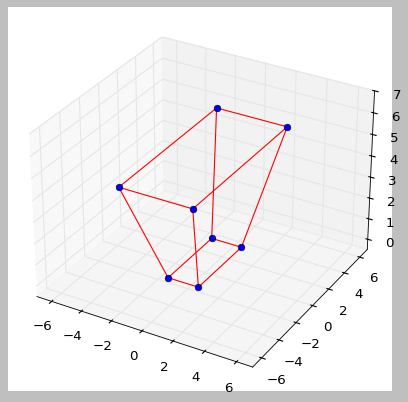

In [34]:
# Source - https://stackoverflow.com/a/69669015
# Posted by Futurologist
# Retrieved 2026-09-03, License - CC BY-SA 4.0

def get_vertices(L, B, I, alpha, beta):
    P = np.empty((8,3), dtype=float)
    Ind = np.array([4,5,6,7])
    #Ind = np.array([0,2,4,6])
    
    P[Ind, 0] = L/2 + I*np.tan(np.pi*alpha/180)
    P[Ind, 1] = B/2 + I*np.tan(np.pi*beta/180)
    P[Ind, 2] = I
    P[5, 0] = - P[5, 0]
    P[7, 1] = - P[7, 1]
    P[6, [0,1]] = - P[6, [0,1]]
    
    Ind = Ind - 4
    P[Ind, 0] = L/2
    P[Ind, 1] = B/2
    P[Ind, 2] = 0
    P[1, 0] = - P[1, 0]
    P[3, 1] = - P[3, 1]
    P[2, [0,1]] = - P[2, [0,1]]
    
    return P


def draw(P):
    l_x = -7
    r_x = 7
    l_y = -7
    r_y = 7
    l_z = -0.5
    r_z = 7
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_xlim((l_x, r_x))
    ax.set_ylim((l_y, r_y))
    ax.set_zlim((l_z, r_z))
    Ind = np.array([[0,1], [1,2], [2,3], [3,0]]) 
    for i in Ind:        
        ax.plot(P[i, 0], P[i, 1], P[i, 2], 'r-')
    Ind = np.array([[4,5], [5,6], [6,7], [7,4]]) 
    for i in Ind:        
        ax.plot(P[i, 0], P[i, 1], P[i, 2], 'r-')
    Ind = np.array([[0,4], [1,5], [2,6], [3,7]]) 
    for i in Ind:        
        ax.plot(P[i, 0], P[i, 1], P[i, 2], 'r-')
    ax.plot(P[:,0], P[:,1], P[:,2], 'bo')
    plt.show()
    return None

L = 2
B = 5
I = 5
alpha = 15
beta = 30
ful = get_vertices(L, B, I, alpha, beta)

draw(ful)
